In [53]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [34]:
# 2013년 SQLDATE, EventCode, GoldsteinScale, ActionGeo_Lat, ActionGeo_Long 컬럼
query = """
SELECT SQLDATE, EventCode, GoldsteinScale, ActionGeo_Lat, ActionGeo_Long
FROM `gdelt-bq.full.events`
WHERE Year = 2013 
  AND ((Actor1Code = 'CHN' AND Actor2Code = 'TWN') OR 
       (Actor1Code = 'TWN' AND Actor2Code = 'CHN'))
"""

# 프로젝트 ID 입력 후 바로 Pandas DataFrame으로 변환
project_id = "project-fe69a478-943f-4a4a-bc6" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

print(df.head())

Downloading: 100%|██████████|
    SQLDATE EventCode  GoldsteinScale  ActionGeo_Lat  ActionGeo_Long
0  20130205       043             2.8        25.0478         121.532
1  20130205       042             1.9        25.0478         121.532
2  20131019       071             7.4        24.0000         121.000
3  20131019       071             7.4        39.9289         116.388
4  20131019       071             7.4        24.0000         121.000


## 0504 EDA 시작

[이상 탐지 기준]

1. NumMentions ≥ ???

2. Growth Rate ≥ ??? (상위 10%)

3. AvgTone ≤ ???

4. Goldstein ≤ ???

5. 특정 EventRootCode

In [35]:
# 2013년부터 2016년 현재까지의 데이터 불러오기
query = """
SELECT 
    SQLDATE, 
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE Year BETWEEN 2013 AND 2026
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
"""

project_id = "project-fe69a478-943f-4a4a-bc6" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

# 결과 확인
print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.")
display(df.head())

Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 493157건의 데이터를 불러왔습니다.


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20150612,070,7.0,6,0.000000,39.9289,116.388,http://www.straitstimes.com/asia/east-asia/chi...
1,20150612,070,7.0,4,0.000000,39.9289,116.388,http://www.straitstimes.com/asia/east-asia/chi...
2,20160611,193,-10.0,6,-2.825553,34.9547,109.297,http://focustaiwan.tw/news/asoc/201606110005.aspx
3,20160611,193,-10.0,4,-2.825553,34.9547,109.297,http://focustaiwan.tw/news/asoc/201606110005.aspx
4,20161105,0841,7.0,2,-4.993910,23.5000,121.000,http://somalireview.com/2016/11/somalia-week-f...


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493157 entries, 0 to 493156
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   SQLDATE         493157 non-null  Int64  
 1   EventCode       493157 non-null  object 
 2   GoldsteinScale  493155 non-null  float64
 3   NumMentions     493157 non-null  Int64  
 4   AvgTone         493157 non-null  float64
 5   ActionGeo_Lat   493109 non-null  float64
 6   ActionGeo_Long  493111 non-null  float64
 7   SOURCEURL       493157 non-null  object 
dtypes: Int64(2), float64(4), object(2)
memory usage: 31.0+ MB


In [37]:
df.describe()

,SQLDATE,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Lat,ActionGeo_Long
count,493157.0,493155.000000,493157.0,493157.000000,493109.000000,493111.000000
mean,20199878.91348,0.374938,10.749473,-1.389321,30.317704,105.972485
std,35433.843821,4.365424,42.733098,2.857387,9.656436,45.626588
min,20130102.0,-10.000000,1.0,-24.000000,-85.622100,-175.000000
25%,20170120.0,-2.000000,2.0,-3.155304,24.000000,116.388000
50%,20201024.0,1.000000,4.0,-1.451855,25.047800,118.318000
75%,20230428.0,3.400000,8.0,0.392157,39.928900,121.275000
max,20260502.0,10.000000,3518.0,21.428571,76.534000,180.000000


In [38]:
df.isna().mean()

SQLDATE           0.000000
EventCode         0.000000
GoldsteinScale    0.000004
NumMentions       0.000000
AvgTone           0.000000
ActionGeo_Lat     0.000097
ActionGeo_Long    0.000093
SOURCEURL         0.000000
dtype: float64

In [39]:
data = df.dropna()

In [40]:
data.isna().sum()

SQLDATE           0
EventCode         0
GoldsteinScale    0
NumMentions       0
AvgTone           0
ActionGeo_Lat     0
ActionGeo_Long    0
SOURCEURL         0
dtype: int64

In [41]:
data.describe()

,SQLDATE,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Lat,ActionGeo_Long
count,493107.0,493107.000000,493107.0,493107.000000,493107.000000,493107.000000
mean,20199879.354805,0.374911,10.749415,-1.389334,30.317685,105.972749
std,35434.028273,4.365343,42.735107,2.857287,9.656451,45.626591
min,20130102.0,-10.000000,1.0,-24.000000,-85.622100,-175.000000
25%,20170120.0,-2.000000,2.0,-3.155322,24.000000,116.388000
50%,20201024.0,1.000000,4.0,-1.451906,25.047800,118.318000
75%,20230428.0,3.400000,8.0,0.392157,39.928900,121.275000
max,20260502.0,10.000000,3518.0,21.428571,76.534000,180.000000


In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493107 entries, 0 to 493156
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   SQLDATE         493107 non-null  Int64  
 1   EventCode       493107 non-null  object 
 2   GoldsteinScale  493107 non-null  float64
 3   NumMentions     493107 non-null  Int64  
 4   AvgTone         493107 non-null  float64
 5   ActionGeo_Lat   493107 non-null  float64
 6   ActionGeo_Long  493107 non-null  float64
 7   SOURCEURL       493107 non-null  object 
dtypes: Int64(2), float64(4), object(2)
memory usage: 34.8+ MB


In [43]:
data.head()

,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20150612,070,7.0,6,0.000000,39.9289,116.388,http://www.straitstimes.com/asia/east-asia/chi...
1,20150612,070,7.0,4,0.000000,39.9289,116.388,http://www.straitstimes.com/asia/east-asia/chi...
2,20160611,193,-10.0,6,-2.825553,34.9547,109.297,http://focustaiwan.tw/news/asoc/201606110005.aspx
3,20160611,193,-10.0,4,-2.825553,34.9547,109.297,http://focustaiwan.tw/news/asoc/201606110005.aspx
4,20161105,0841,7.0,2,-4.993910,23.5000,121.000,http://somalireview.com/2016/11/somalia-week-f...


In [55]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')

In [56]:
## 일별 기사량
daily = df.groupby('SQLDATE').agg({
    'NumMentions': 'sum'
}).reset_index()

daily = daily.sort_values('SQLDATE')

In [57]:
## 7 / 14 / 30일 이동평균 생성
daily['ma_7'] = daily['NumMentions'].rolling(7).mean()
daily['ma_14'] = daily['NumMentions'].rolling(14).mean()
daily['ma_30'] = daily['NumMentions'].rolling(30).mean()

In [58]:
## 연도 컬럼 생성
daily['year'] = daily['SQLDATE'].dt.year

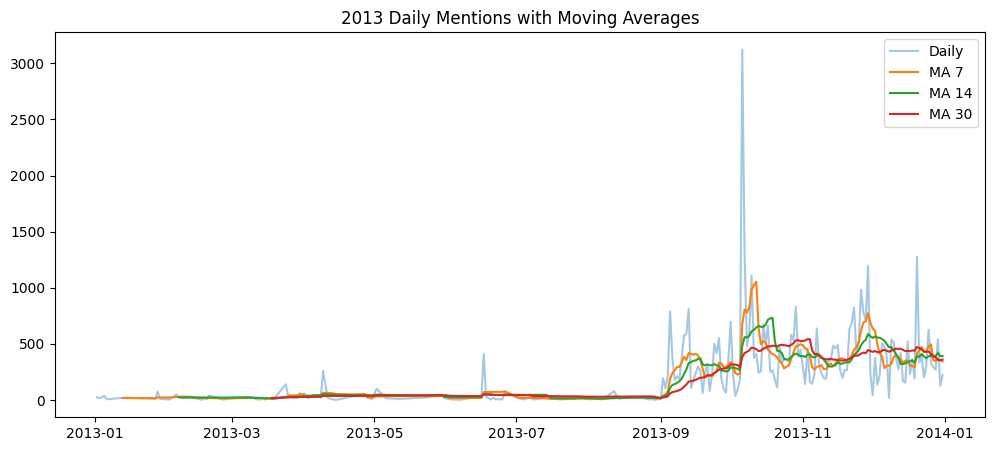

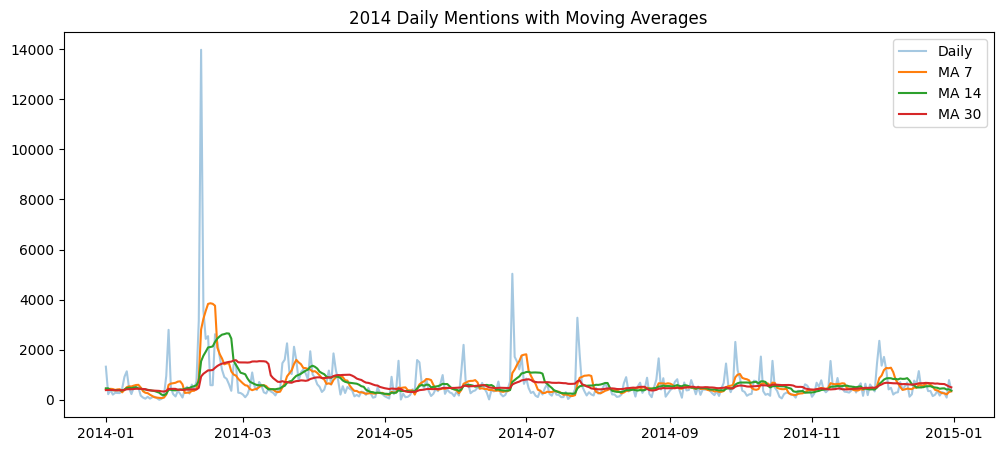

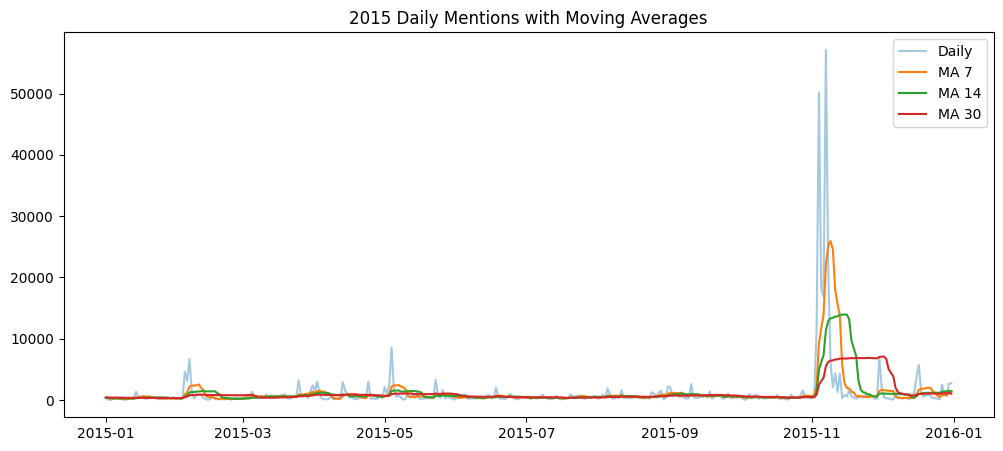

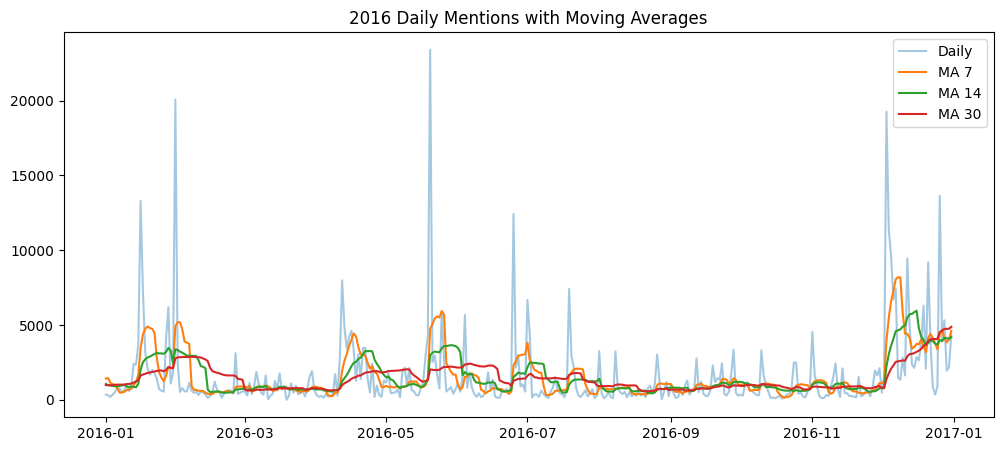

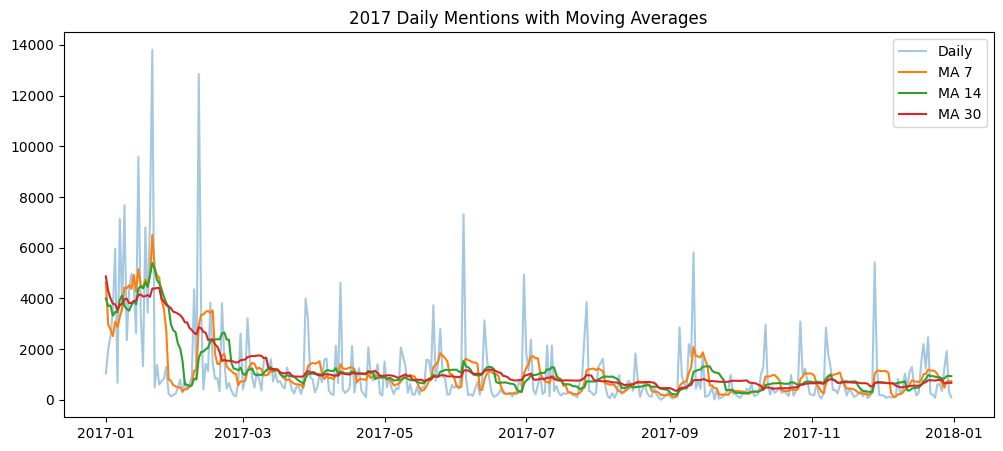

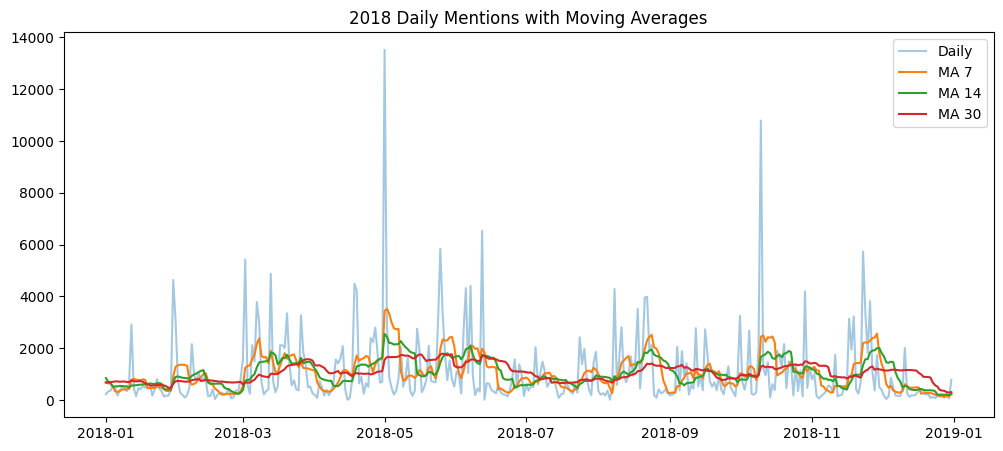

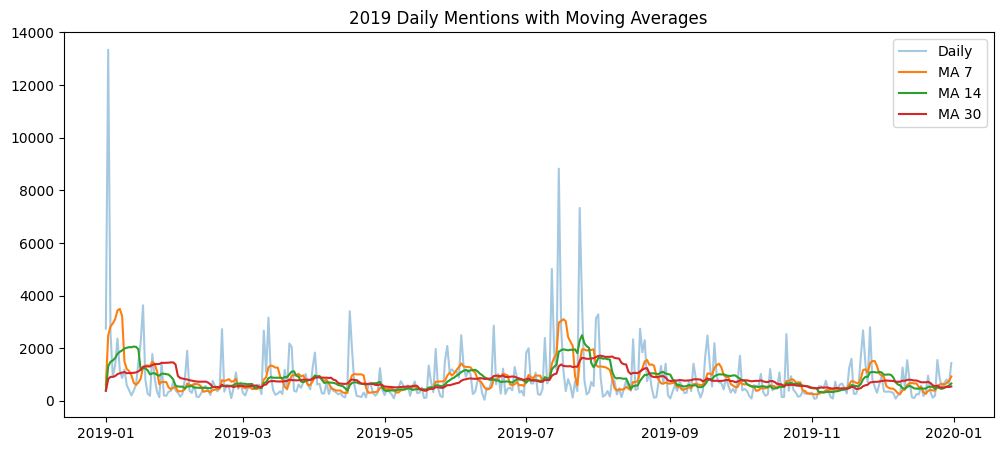

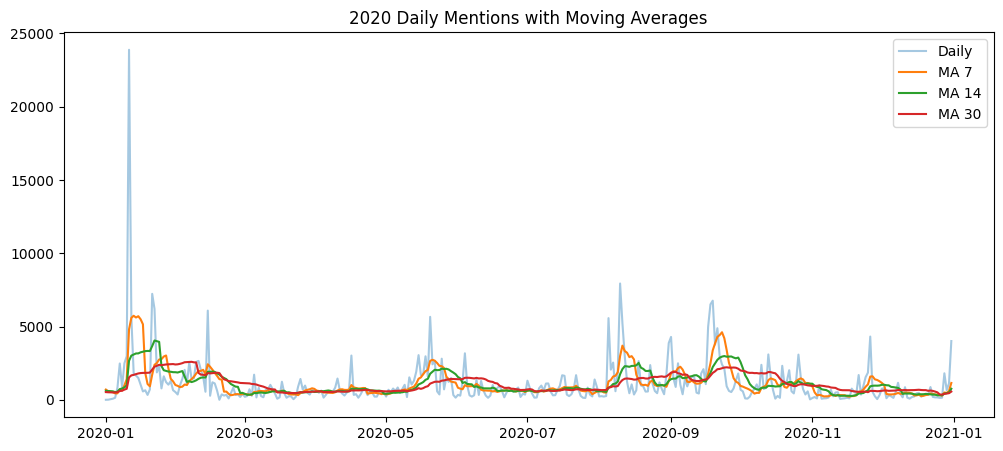

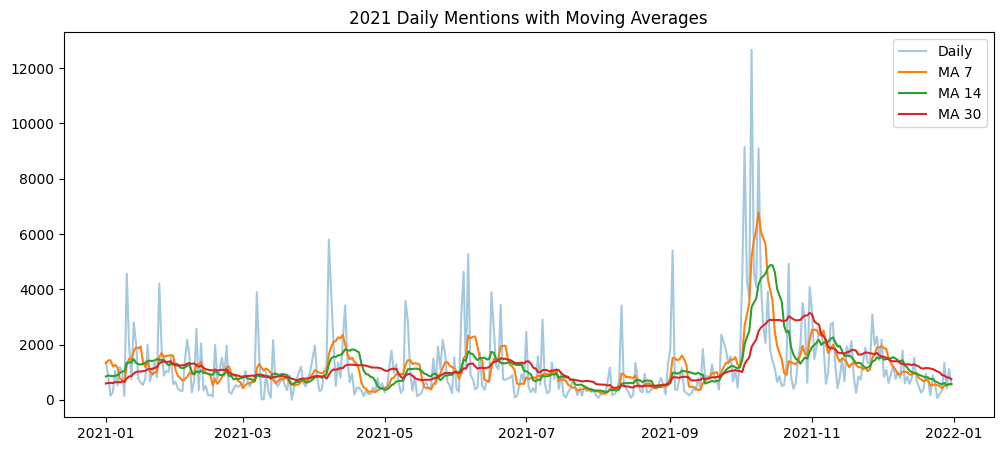

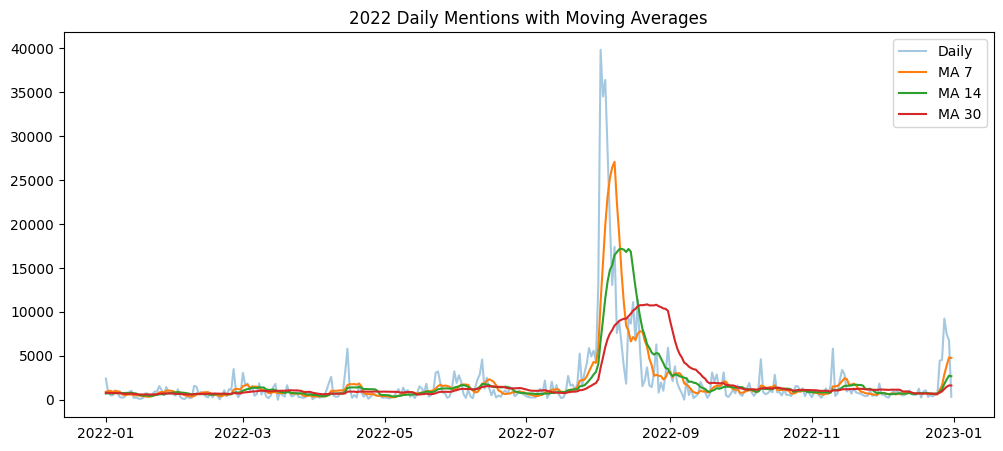

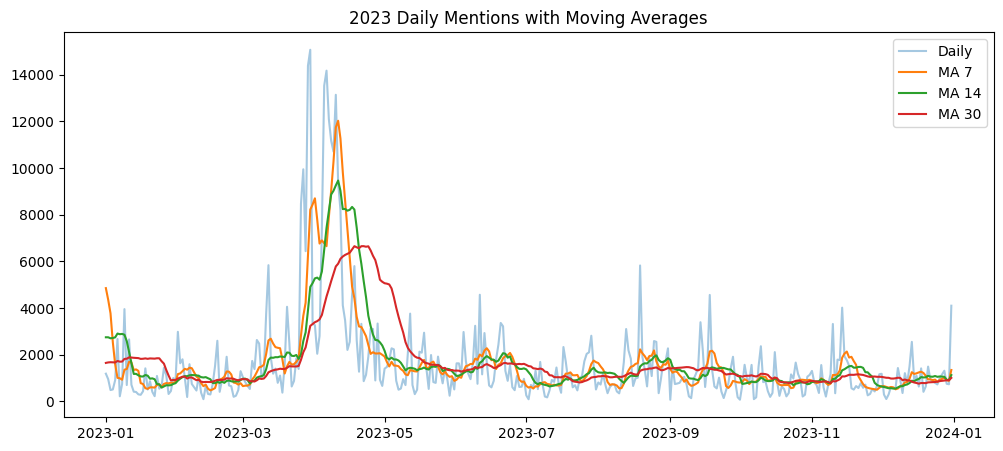

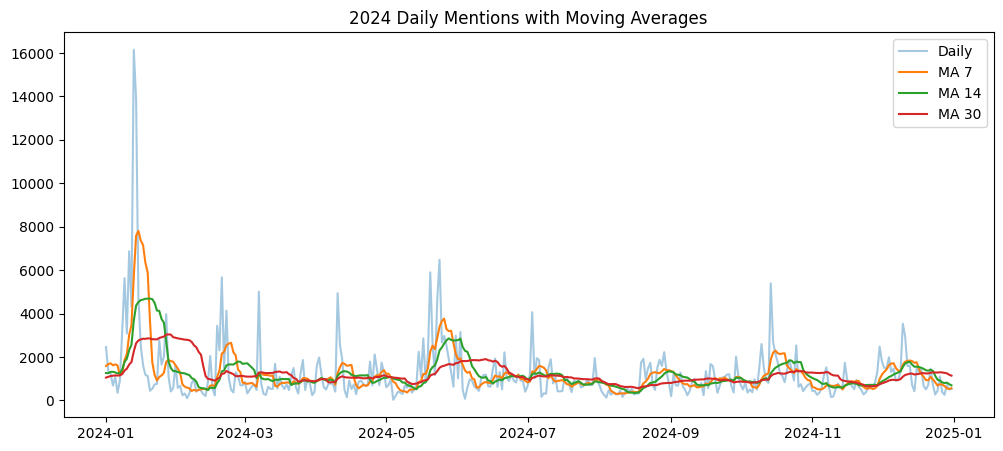

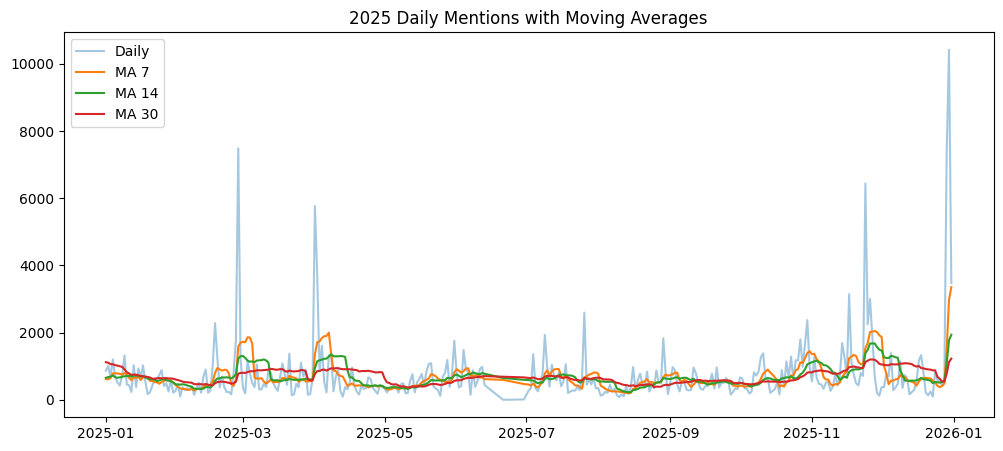

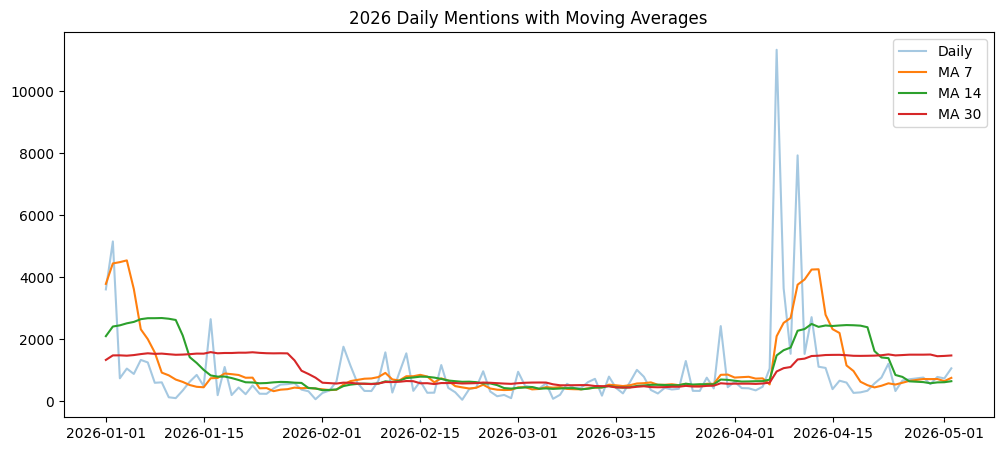

In [59]:
import matplotlib.pyplot as plt

years = sorted(daily['year'].unique())

for y in years:
    temp = daily[daily['year'] == y]
    
    plt.figure(figsize=(12,5))
    
    plt.plot(temp['SQLDATE'], temp['NumMentions'], label='Daily', alpha=0.4)
    plt.plot(temp['SQLDATE'], temp['ma_7'], label='MA 7')
    plt.plot(temp['SQLDATE'], temp['ma_14'], label='MA 14')
    plt.plot(temp['SQLDATE'], temp['ma_30'], label='MA 30')
    
    plt.title(f"{y} Daily Mentions with Moving Averages")
    plt.legend()
    plt.show()

- 대부분 평상시에는 낮고 안정적
- 이벤트 발생 시: 특정 시점에서 매우 큰 스파이크 있음.

## Window 별 분석
### 7일
- 스파이크 거의 그대로 따라감, 급격한 상승/하강 그대로 반영됨
- 하지만 너무 민감한 것 같음 -> 거의 모든 작은 변동까지 잡아서.. => False Positive 많아질 문제 가능성

### 14일
- 스파이크. 보이긴 하는데 적당히 완화된 모습.
- 추세도 유지되고 있고, 스파이크 반영되어 있음
- 7일에 비해, 노이즈는 줄어듦

### 30일
- 스파이크가 조금 눌린 분포
- 하지만, 전체적인 흐름은 잘 잡는 듯
- 중요한 이벤트가 희석?되지 않을까...?

## 연도별 전체 패턴
- 매우 극단적인 스파이크 존재 (예: 2015, 2022 등등..)
- 평소 구간은 낮고 안정적임 -> baseline으로 기준 잡고 가도 될 듯.
- 어떤 이벤트 발생 후, 여운 구간 존재
    - 왜냐하면, 무력 충돌 이라는 이벤트 발생 당일, 뉴스는 폭발적으로 증가함, 그리고 이후 계속 후속 기사들이 계속 나오기 때문
    - **이벤트는 단발성 스파이크가 아니라 일정 기간 후속 보도가 이어지는 패턴을 보임 => 이러한 여운 구간을 적절히 반영할 수 있는 기간 설정이 매우 중요함.**

- 이벤트 발생 시, 일정 기간 지속됨.. (며칠 ~ 몇 주 동안 유지됨)
    - 이런 관점에서는 한달은 너무 길지도..

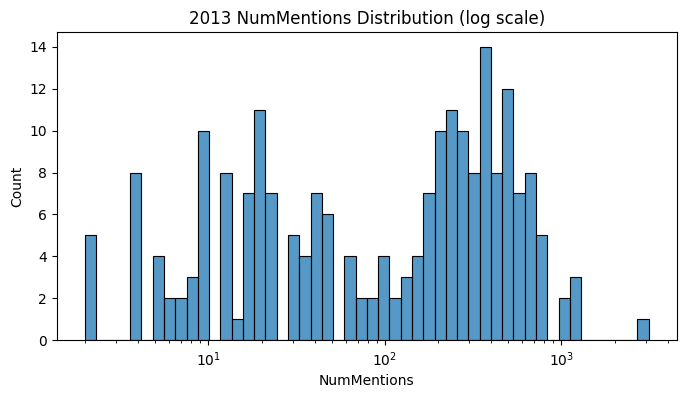

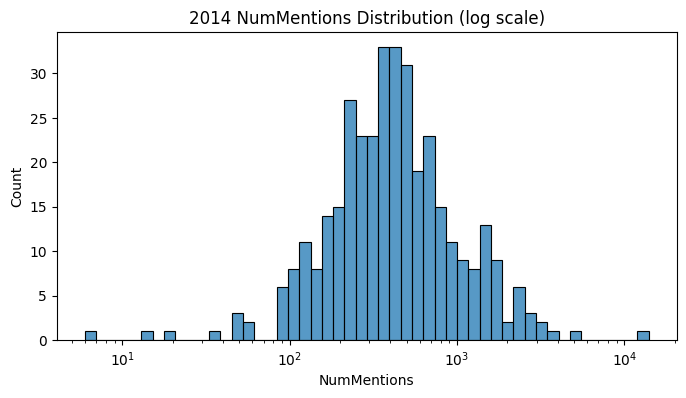

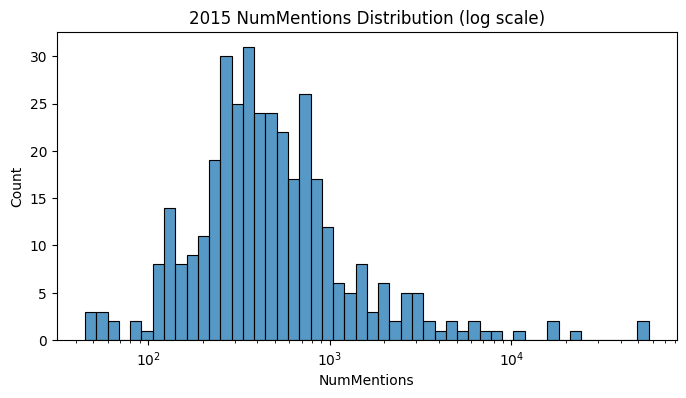

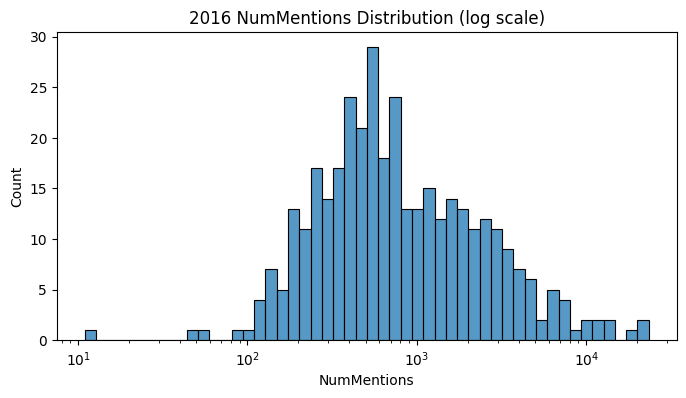

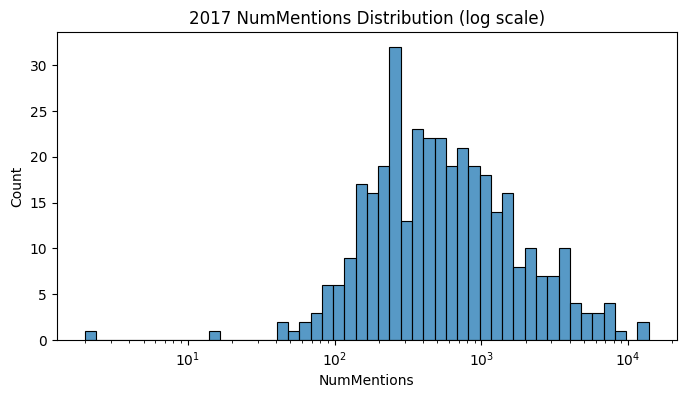

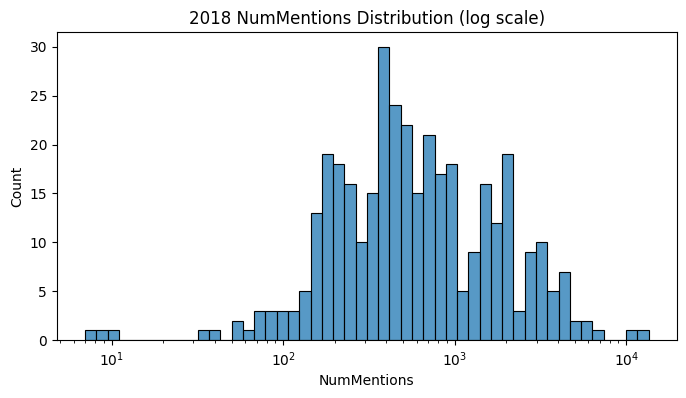

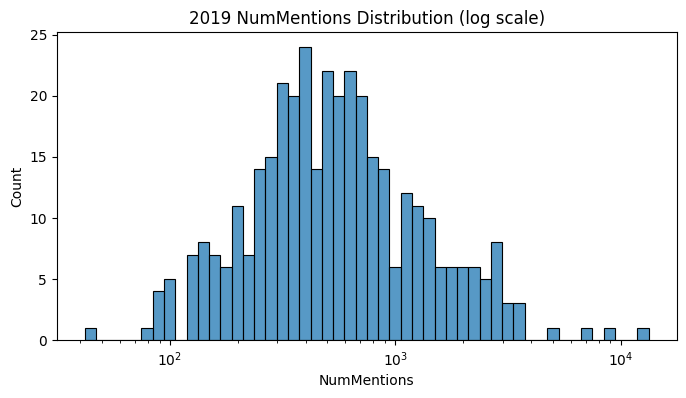

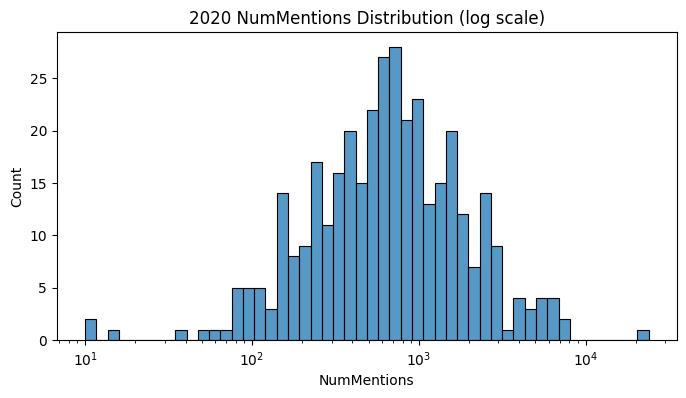

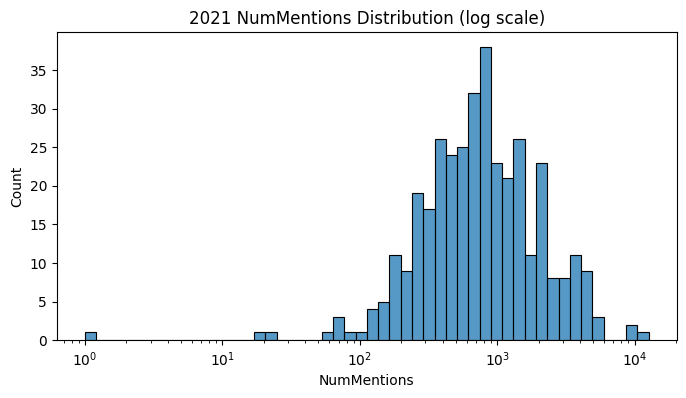

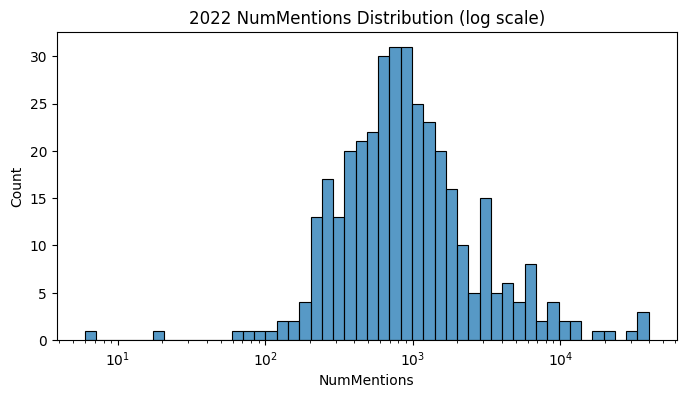

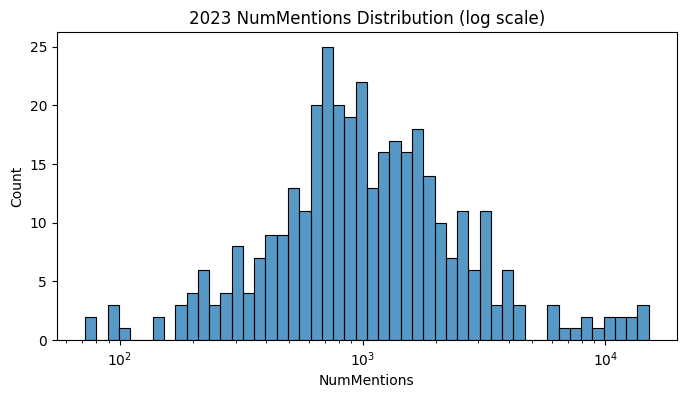

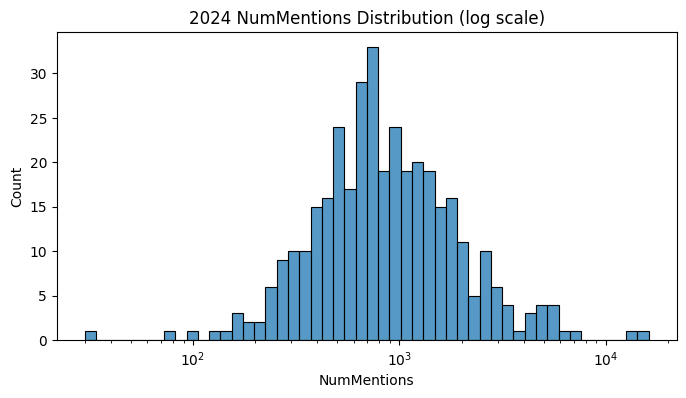

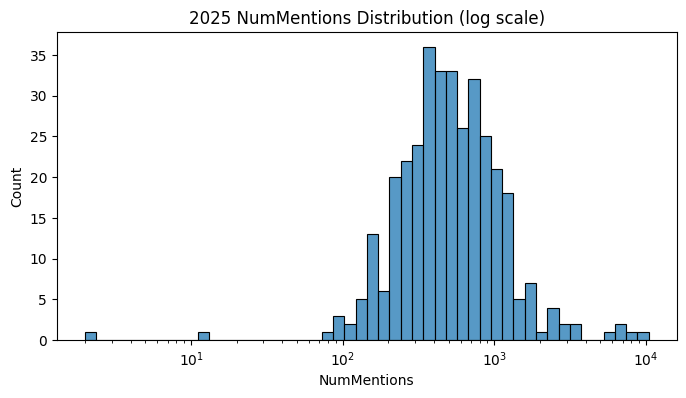

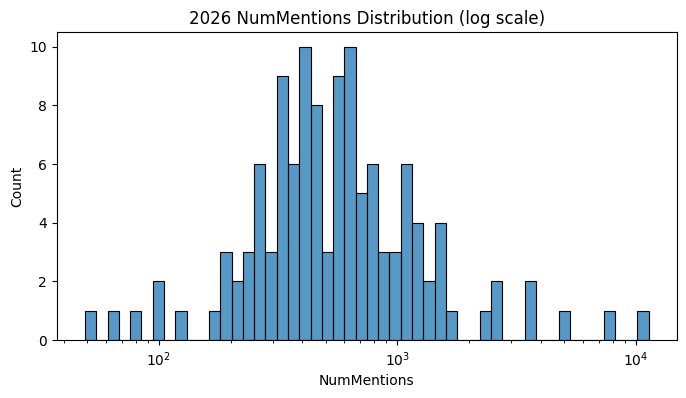

In [61]:
## 연도별 분포
import seaborn as sns

for y in years:
    temp = daily[daily['year'] == y]
    
    plt.figure(figsize=(8,4))
    sns.histplot(temp['NumMentions'], bins=50, log_scale=True)
    
    plt.title(f"{y} NumMentions Distribution (log scale)")
    plt.show()

In [62]:
## 연도별 통계 비교
summary = daily.groupby('year')['NumMentions'].describe()
print(summary)

      count         mean          std   min     25%    50%     75%      max
year                                                                       
2013  217.0   239.737327   325.057118   2.0    20.0  144.0   367.0   3121.0
2014  364.0   629.214286   924.946204   6.0   240.0  405.5   681.5  13967.0
2015  364.0  1191.222527   4400.23358  45.0  260.75  416.0  756.25  57137.0
2016  366.0  1578.915301  2651.544025  11.0  369.25  660.5  1690.5  23400.0
2017  361.0  1075.933518   1639.20234   2.0   246.0  497.0  1134.0  13807.0
2018  365.0  1040.939726  1388.051604   7.0   275.0  525.0  1366.0  13521.0
2019  364.0   833.085165  1121.555158  42.0  303.75  507.0  899.25  13341.0
2020  365.0  1120.380822  1714.467617  10.0   327.0  665.0  1304.0  23886.0
2021  365.0  1174.734247  1351.830744   1.0   402.0  750.0  1417.0  12665.0
2022  365.0  1922.526027  4178.639809   6.0   470.0  838.0  1585.0  39815.0
2023  363.0  1637.619835  2189.781966  72.0   619.5  971.0  1732.0  15066.0
2024  365.0 

# 증가율
- 7 / 14 / 30 기준 증가율 계산
    - 예: (오늘 기사량 - 14일 평균) / 14일 평균

- 증가율 분포 확인 -> 대부분 어느 범위에 있고, 어디부터 이상이라고 판단 가능할까?
- 상위 퍼센티지 확인 -> 상위 몇%부터 '비정상적으로 증가'한다라고 볼 것인가?
- 임계값 후보 선정하기

In [69]:
# 7일 이동평균 기준 증가율
daily['growth_rate_7'] = (daily['NumMentions'] - daily['ma_7']) / daily['ma_7']

# NaN 제거
growth = daily['growth_rate_7'].dropna()

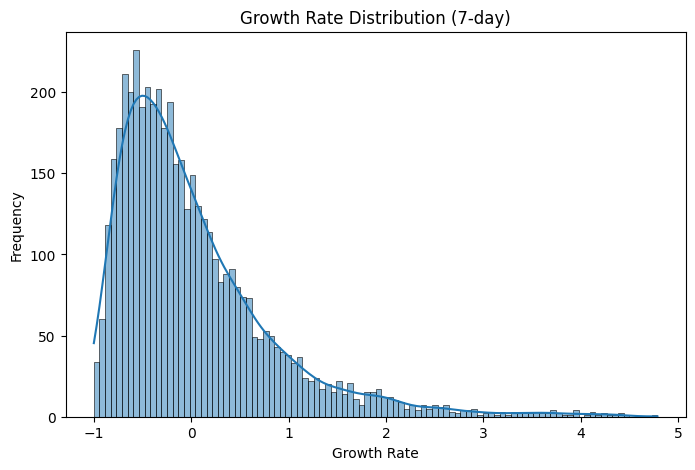

In [70]:
plt.figure(figsize=(8,5))
sns.histplot(growth, bins=100, kde=True)

plt.title("Growth Rate Distribution (7-day)")
plt.xlabel("Growth Rate")
plt.ylabel("Frequency")

plt.show()

In [71]:
percentiles = growth.describe(percentiles=[0.9, 0.95, 0.99])
print(percentiles)

count      4687.0
mean     0.028769
std      0.812114
min     -0.998135
50%     -0.189541
90%       1.04151
95%      1.635824
99%      3.098766
max       4.78629
Name: growth_rate_7, dtype: Float64


In [72]:
p90 = growth.quantile(0.90)
p95 = growth.quantile(0.95)
p99 = growth.quantile(0.99)

print(f"90% threshold: {p90:.2f}")
print(f"95% threshold: {p95:.2f}")
print(f"99% threshold: {p99:.2f}")

90% threshold: 1.04
95% threshold: 1.64
99% threshold: 3.10


In [63]:
# 14일 이동평균 기준 증가율
daily['growth_rate'] = (daily['NumMentions'] - daily['ma_14']) / daily['ma_14']

# NaN 제거
growth = daily['growth_rate'].dropna()

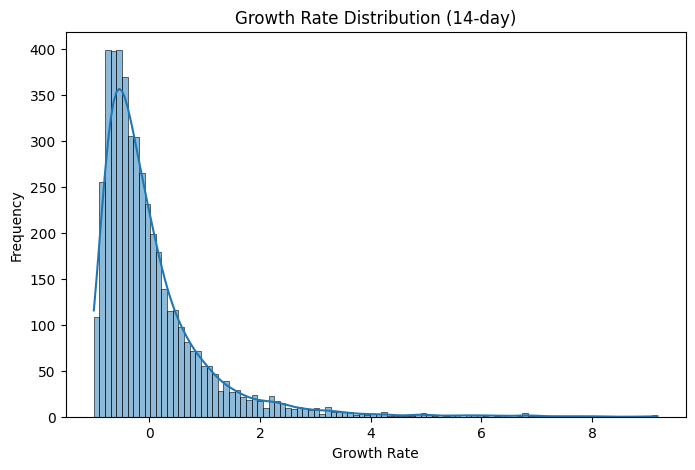

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(growth, bins=100, kde=True)

plt.title("Growth Rate Distribution (14-day)")
plt.xlabel("Growth Rate")
plt.ylabel("Frequency")

plt.show()

In [67]:
percentiles = growth.describe(percentiles=[0.9, 0.95, 0.99])
print(percentiles)

count      4680.0
mean     0.041371
std      1.029896
min     -0.998239
50%     -0.253329
90%      1.130511
95%      1.938814
99%      4.265214
max      9.178036
Name: growth_rate, dtype: Float64


In [68]:
p90 = growth.quantile(0.90)
p95 = growth.quantile(0.95)
p99 = growth.quantile(0.99)

print(f"90% threshold: {p90:.2f}")
print(f"95% threshold: {p95:.2f}")
print(f"99% threshold: {p99:.2f}")

90% threshold: 1.13
95% threshold: 1.94
99% threshold: 4.27


In [73]:
# 30일 이동평균 기준 증가율
daily['growth_rate_30'] = (daily['NumMentions'] - daily['ma_30']) / daily['ma_30']

# NaN 제거
growth = daily['growth_rate_30'].dropna()

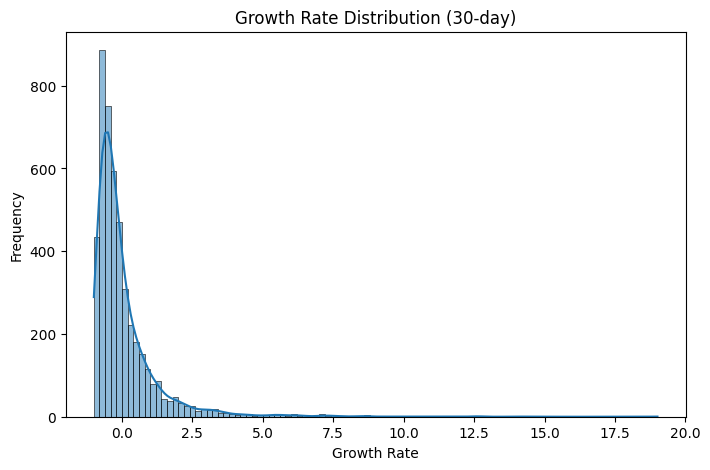

In [75]:
plt.figure(figsize=(8,5))
sns.histplot(growth, bins=100, kde=True)

plt.title("Growth Rate Distribution (30-day)")
plt.xlabel("Growth Rate")
plt.ylabel("Frequency")

plt.show()

In [76]:
percentiles = growth.describe(percentiles=[0.9, 0.95, 0.99])
print(percentiles)

count       4664.0
mean      0.055498
std       1.274104
min      -0.998686
50%      -0.314681
90%       1.220339
95%       2.135917
99%       5.523679
max      19.009708
Name: growth_rate_30, dtype: Float64


In [77]:
p90 = growth.quantile(0.90)
p95 = growth.quantile(0.95)
p99 = growth.quantile(0.99)

print(f"90% threshold: {p90:.2f}")
print(f"95% threshold: {p95:.2f}")
print(f"99% threshold: {p99:.2f}")

90% threshold: 1.22
95% threshold: 2.14
99% threshold: 5.52


## 분포 해석
### 공통 특징
- 오른쪽 꼬리 존재
- 음수 구간 존재함 -> 감소하는 날도 있다~ => 정상적인 변동임.

## Window별 차이 및 threshold 값
### 7일
- tail 이 짧음 (최대 5), threshold도 낮음 
- => 작은 증가도 '이상'으로 잡힘. => 과탐지 위험.
- 95% = 1.64 → 164% 증가
    - 너무 낮음

### 14일
- tail이 좀 더 길어짐 (~ 9), 분포가 상대적으로 더 안정적임
- 7일보다 진짜 이벤트만 강조된 것이 아닐까..해석
- 95% = 1.94 → 약 2배 증가
    - **평소보다 2배 이상 증가하면 스파이크.. => 기준치도 너무 높지 않고 직관적임**

### 30일
- tail 젤 김 (~ 20), 분포가 상대적으로 너무 퍼져있음
- => 이렇게 되면, 스파이크 기준이 너무 높아져서, 중요한 이벤트를 놓칠 수 있을 것 같다.
- 95% = 2.14
    - 이것도 약 2배 이상 증가하면 스파이크라 정의할 수 있지만, 분포를 보면, 꼬리가 매우 길어서...

### 정리
- **진짜 중요한 이벤트는 최소 2배 이상 증가함**